<a href="https://colab.research.google.com/github/krish52-git/M/blob/main/AMAZON%20SALES%20ANALYSYS%201%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df=pd.read_csv('customer_shopping_behavior.csv')

In [14]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [16]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [17]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [18]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [19]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [20]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [21]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [22]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [23]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [24]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [25]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [26]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [27]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [28]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [29]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

# Task
Perform a comprehensive exploratory data analysis (EDA) on the "customer_shopping_behavior.csv" dataset to understand customer behavior and product performance. This analysis will include:
1.  **Revenue by Gender**: Calculate total purchase amounts for male and female customers and visualize the comparison.
2.  **High-Spending Discount Users**: Identify and count customers who received a discount and spent above the overall average purchase amount.
3.  **Top Products by Review Rating**: Determine and visualize the top 5 products based on their average review ratings.
4.  **Purchase Amounts by Shipping Type**: Compare and visualize average purchase amounts for 'Standard' and 'Express' shipping types.
5.  **Subscriber Spending Analysis**: Compare average purchase amounts and total revenue between subscribed and non-subscribed customers, using two separate visualizations.
6.  **Product Discount Usage**: Identify and visualize the top 5 products with the highest percentage of discount usage.
7.  **Customer Segmentation by Purchases**: Segment customers into 'New' (0-5 purchases), 'Returning' (6-20 purchases), and 'Loyal' (>20 purchases) and visualize the distribution.
8.  **Top Products per Category**: For each product category, identify and visualize the top 3 most purchased items.
9.  **Repeat Buyers and Subscription Likelihood**: Analyze if customers with more than 5 previous purchases are more likely to subscribe and visualize the proportion of subscribed vs. non-subscribed repeat buyers versus other customers.
10. **Revenue by Age Group**: Calculate and visualize the total revenue generated by different age groups.
Finally, summarize the key insights derived from all analyses and visualizations.

In [31]:
revenue_by_gender = df.groupby('gender')['purchase_amount'].sum()
print(revenue_by_gender)

gender
Female     75191
Male      157890
Name: purchase_amount, dtype: int64


**Reasoning**:
Now that the total purchase amount by gender has been calculated, I will create a bar chart to visualize this comparison, adding appropriate labels and a title for clarity as per the subtask instructions.



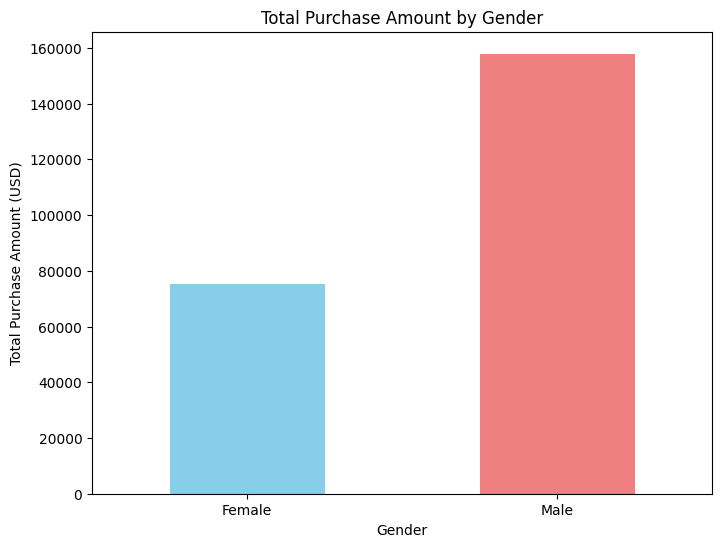

In [32]:
#Analyze Revenue by Gender

plt.figure(figsize=(8, 6))
revenue_by_gender.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Total Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=0)
plt.show()

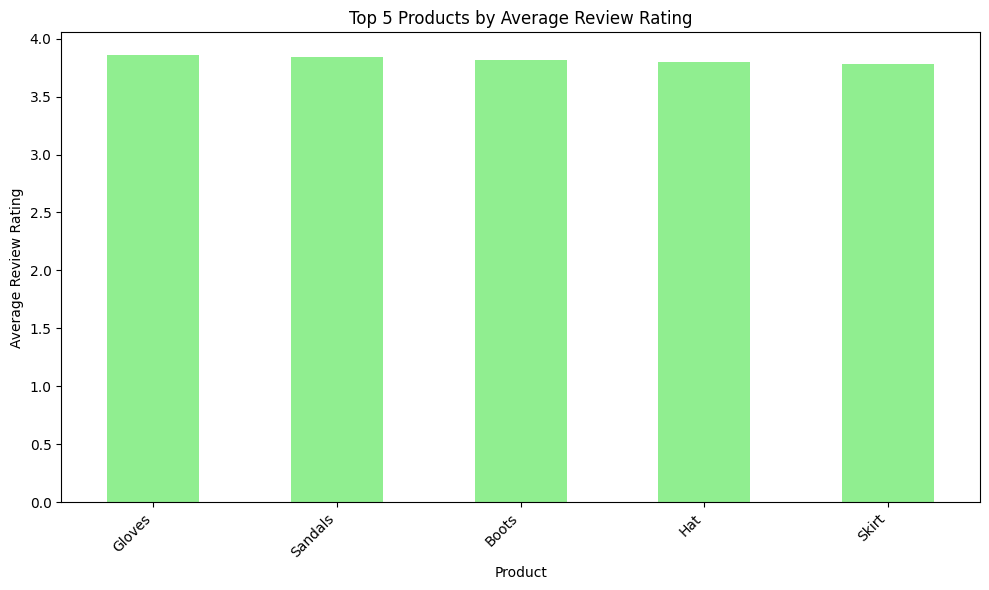

In [37]:
#Top 5 Products by Average Review Rating
plt.figure(figsize=(10, 6))
top_5_products.plot(kind='bar', color='lightgreen')
plt.title('Top 5 Products by Average Review Rating')
plt.xlabel('Product')
plt.ylabel('Average Review Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
shipping_type_filter = df[df['shipping_type'].isin(['Standard', 'Express'])]
avg_purchase_by_shipping = shipping_type_filter.groupby('shipping_type')['purchase_amount'].mean()
print(avg_purchase_by_shipping)

shipping_type
Express     60.475232
Standard    58.460245
Name: purchase_amount, dtype: float64


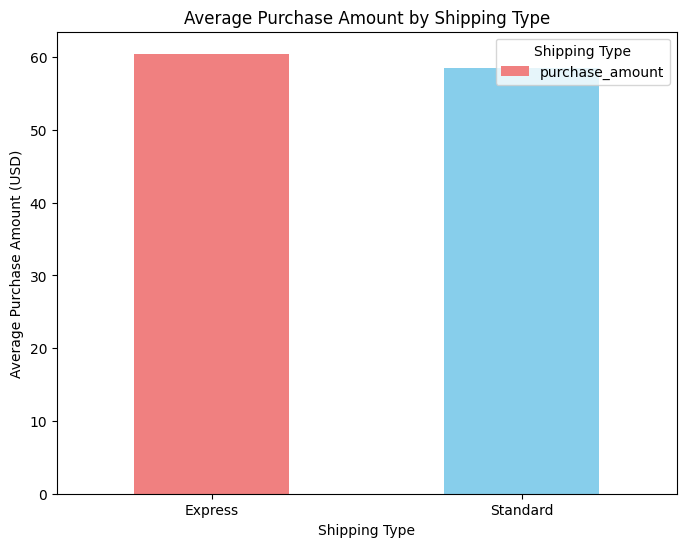

In [39]:
#Compare Purchase Amounts by Shipping Type

plt.figure(figsize=(8, 6))
avg_purchase_by_shipping.plot(kind='bar', color=['lightcoral', 'skyblue'])
plt.title('Average Purchase Amount by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Average Purchase Amount (USD)')
plt.xticks(rotation=0)
plt.legend(title='Shipping Type')
plt.show()

In [40]:
avg_purchase_by_subscription = df.groupby('subscription_status')['purchase_amount'].mean()
total_revenue_by_subscription = df.groupby('subscription_status')['purchase_amount'].sum()

print("Average Purchase Amount by Subscription Status:\n", avg_purchase_by_subscription)
print("\nTotal Revenue by Subscription Status:\n", total_revenue_by_subscription)

Average Purchase Amount by Subscription Status:
 subscription_status
No     59.865121
Yes    59.491928
Name: purchase_amount, dtype: float64

Total Revenue by Subscription Status:
 subscription_status
No     170436
Yes     62645
Name: purchase_amount, dtype: int64


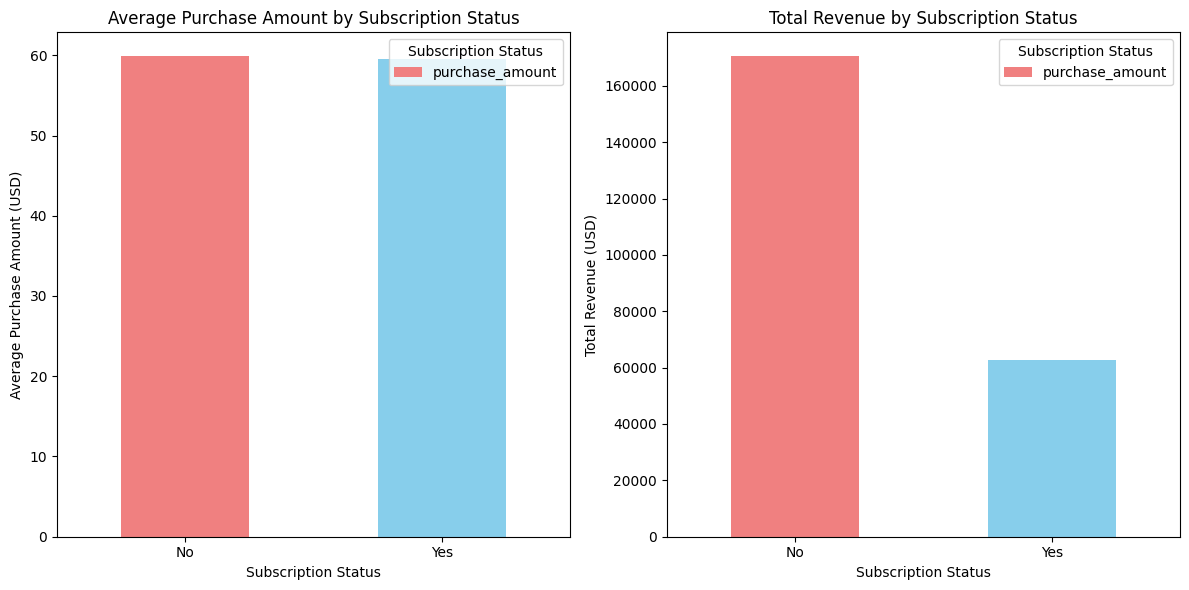

In [41]:
#Analyze Subscriber Spending

plt.figure(figsize=(12, 6))

# Plot for Average Purchase Amount
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
avg_purchase_by_subscription.plot(kind='bar', color=['lightcoral', 'skyblue'])
plt.title('Average Purchase Amount by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Average Purchase Amount (USD)')
plt.xticks(rotation=0)
plt.legend(title='Subscription Status')

# Plot for Total Revenue
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
total_revenue_by_subscription.plot(kind='bar', color=['lightcoral', 'skyblue'])
plt.title('Total Revenue by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=0)
plt.legend(title='Subscription Status')

plt.tight_layout()
plt.show()

In [42]:
discount_usage_by_product = df.groupby('item_purchased')['discount_applied'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
top_5_discounted_products = discount_usage_by_product.nlargest(5)
print("Top 5 Products by Discount Usage Percentage:\n", top_5_discounted_products)

Top 5 Products by Discount Usage Percentage:
 item_purchased
Hat         50.000000
Sneakers    49.655172
Coat        49.068323
Sweater     48.170732
Pants       47.368421
Name: discount_applied, dtype: float64


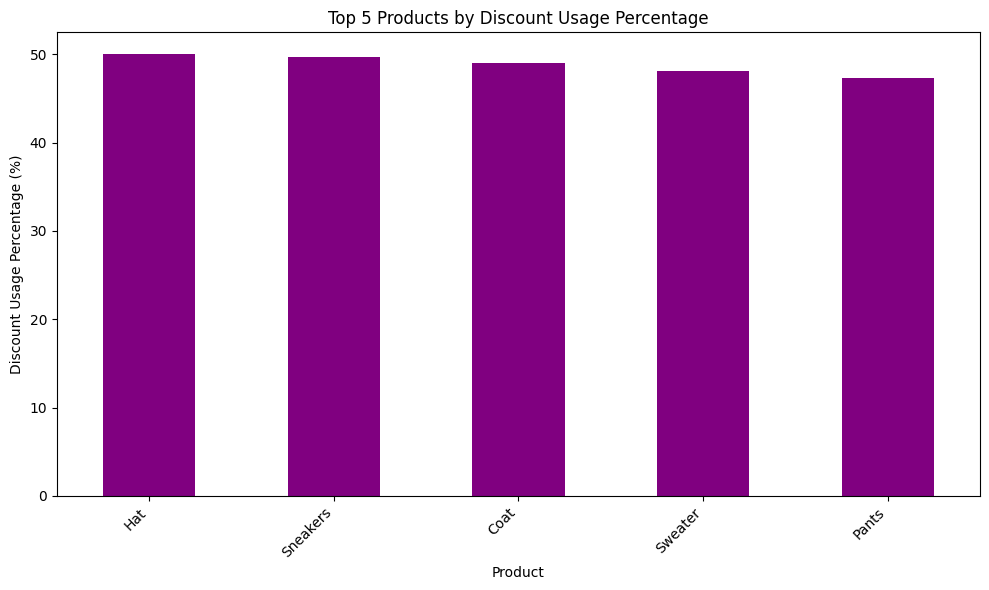

In [43]:
#Top 5 Products with Discount Usage

plt.figure(figsize=(10, 6))
top_5_discounted_products.plot(kind='bar', color='purple')
plt.title('Top 5 Products by Discount Usage Percentage')
plt.xlabel('Product')
plt.ylabel('Discount Usage Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
bins = [-1, 5, 20, df['previous_purchases'].max()]
labels = ['New', 'Returning', 'Loyal']
df['customer_segment'] = pd.cut(df['previous_purchases'], bins=bins, labels=labels, right=True)

customer_segment_counts = df['customer_segment'].value_counts()
print(customer_segment_counts)

customer_segment
Loyal        2339
Returning    1137
New           424
Name: count, dtype: int64


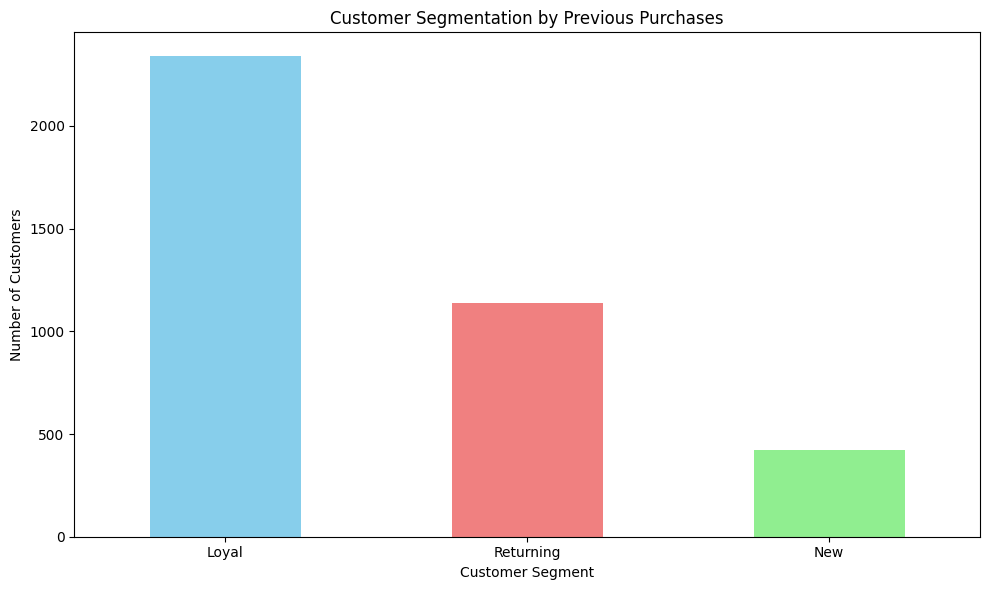

In [45]:
#Segment Customers by Previous Purchases

plt.figure(figsize=(10, 6))
customer_segment_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Customer Segmentation by Previous Purchases')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
purchase_counts_by_category = df.groupby(['category', 'item_purchased']).size().reset_index(name='purchase_count')

top_products_per_category = purchase_counts_by_category.groupby('category').apply(lambda x: x.nlargest(3, 'purchase_count')).reset_index(drop=True)

print(top_products_per_category)

       category item_purchased  purchase_count
0   Accessories        Jewelry             171
1   Accessories           Belt             161
2   Accessories     Sunglasses             161
3      Clothing         Blouse             171
4      Clothing          Pants             171
5      Clothing          Shirt             169
6      Footwear        Sandals             160
7      Footwear          Shoes             150
8      Footwear       Sneakers             145
9     Outerwear         Jacket             163
10    Outerwear           Coat             161


/tmp/ipykernel_248/3730871580.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_products_per_category = purchase_counts_by_category.groupby('category').apply(lambda x: x.nlargest(3, 'purchase_count')).reset_index(drop=True)


/tmp/ipykernel_248/4244610135.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_products_per_category = purchase_counts_by_category.groupby('category').apply(lambda x: x.nlargest(3, 'purchase_count')).reset_index(drop=True)


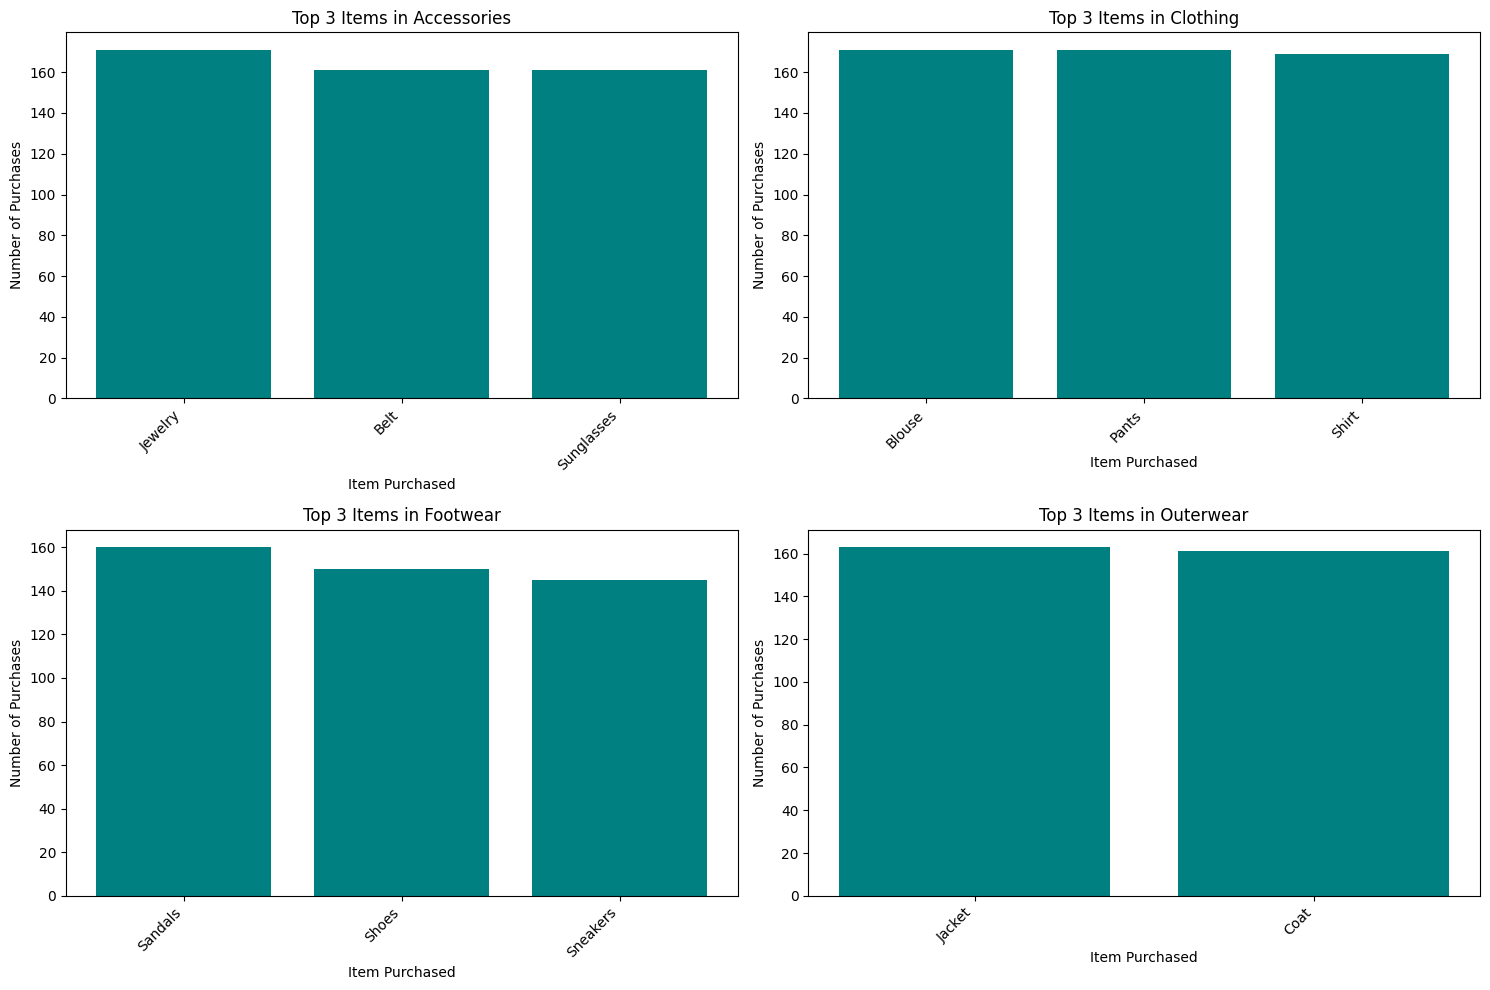

In [49]:
#Top 3 Products per Category

purchase_counts_by_category = df.groupby(['category', 'item_purchased']).size().reset_index(name='purchase_count')

# Corrected: Removed 'include_groups=False' from the groupby call to fix the TypeError.
# The DeprecationWarning from the previous step might still occur if the pandas version is old,
# but this fixes the TypeError first.
top_products_per_category = purchase_counts_by_category.groupby('category').apply(lambda x: x.nlargest(3, 'purchase_count')).reset_index(drop=True)

# Visualize the top products per category
unique_categories = top_products_per_category['category'].unique()
num_categories = len(unique_categories)

# Determine grid size for subplots
rows = (num_categories + 1) // 2  # At least 1 row, 2 columns per row
if rows == 0: rows = 1 # Ensure at least one row for edge case where num_categories is 0 or 1

plt.figure(figsize=(15, 5 * rows))

for i, category in enumerate(unique_categories):
    plt.subplot(rows, 2, i + 1)
    category_data = top_products_per_category[top_products_per_category['category'] == category]
    plt.bar(category_data['item_purchased'], category_data['purchase_count'], color='teal')
    plt.title(f'Top 3 Items in {category}')
    plt.xlabel('Item Purchased')
    plt.ylabel('Number of Purchases')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

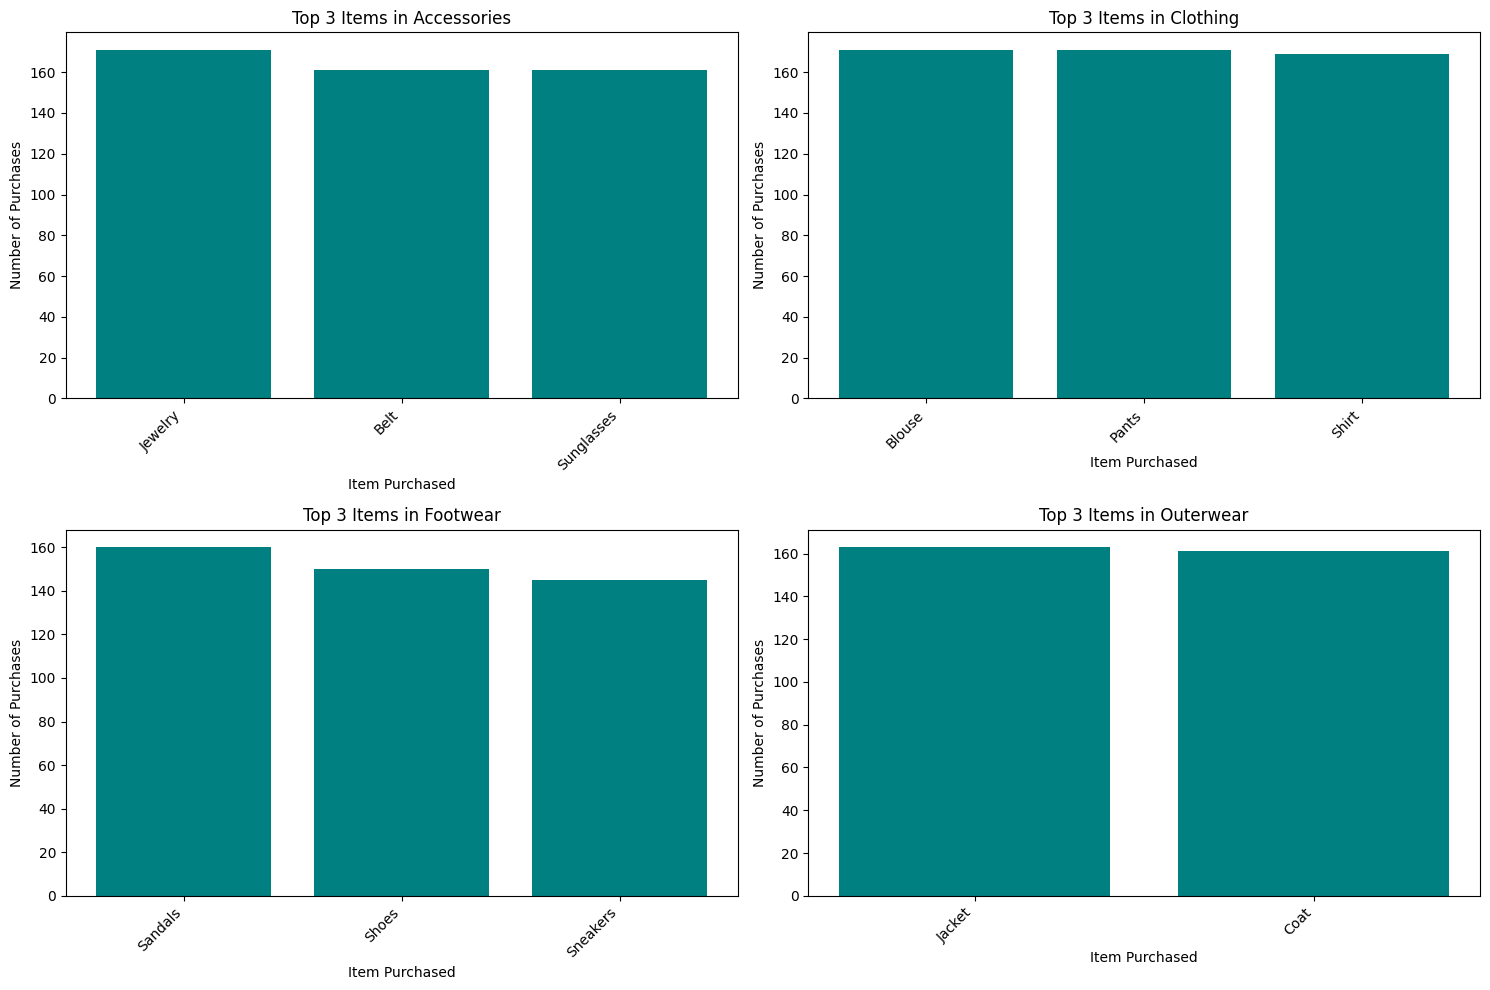

In [50]:
purchase_counts_by_category = df.groupby(['category', 'item_purchased']).size().reset_index(name='purchase_count')

# Corrected approach to find top products per category, avoiding DeprecationWarning
top_products_per_category = purchase_counts_by_category.sort_values(
    ['category', 'purchase_count'],
    ascending=[True, False]
).groupby('category').head(3).reset_index(drop=True)

# Visualize the top products per category
unique_categories = top_products_per_category['category'].unique()
num_categories = len(unique_categories)

# Determine grid size for subplots
rows = (num_categories + 1) // 2  # At least 1 row, 2 columns per row
if rows == 0: rows = 1 # Ensure at least one row for edge case where num_categories is 0 or 1

plt.figure(figsize=(15, 5 * rows))

for i, category in enumerate(unique_categories):
    plt.subplot(rows, 2, i + 1)
    category_data = top_products_per_category[top_products_per_category['category'] == category]
    plt.bar(category_data['item_purchased'], category_data['purchase_count'], color='teal')
    plt.title(f'Top 3 Items in {category}')
    plt.xlabel('Item Purchased')
    plt.ylabel('Number of Purchases')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [51]:
df['buyer_type'] = df['previous_purchases'].apply(lambda x: 'Repeat Buyer' if x > 5 else 'Other Customer')

# Display the first few rows to verify the new column
df[['previous_purchases', 'buyer_type']].head()

,previous_purchases,buyer_type
0,14,Repeat Buyer
1,2,Other Customer
2,23,Repeat Buyer
3,49,Repeat Buyer
4,31,Repeat Buyer


In [52]:
subscription_likelihood = df.groupby(['buyer_type', 'subscription_status']).size().unstack(fill_value=0)

# Calculate proportions
subscription_likelihood_prop = subscription_likelihood.apply(lambda x: x / x.sum(), axis=1)

print("Subscription Likelihood by Buyer Type (Proportions):\n", subscription_likelihood_prop)

Subscription Likelihood by Buyer Type (Proportions):
 subscription_status        No       Yes
buyer_type                             
Other Customer       0.775943  0.224057
Repeat Buyer         0.724396  0.275604


<Figure size 1000x600 with 0 Axes>

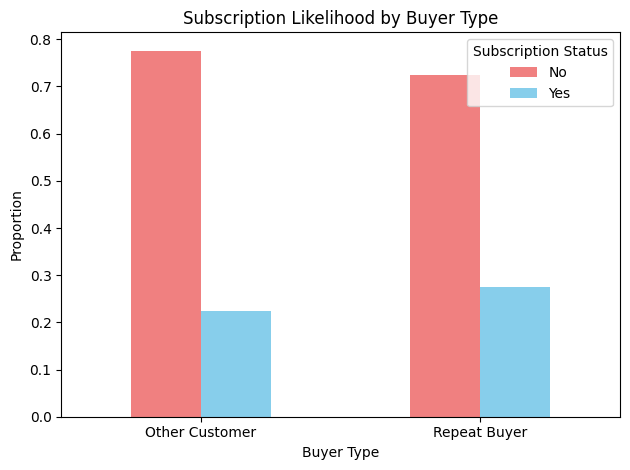

In [53]:
#Repeat Buyers and Subscription Likelihood

plt.figure(figsize=(10, 6))
subscription_likelihood_prop.plot(kind='bar', color=['lightcoral', 'skyblue'])
plt.title('Subscription Likelihood by Buyer Type')
plt.xlabel('Buyer Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Subscription Status')
plt.tight_layout()
plt.show()

In [54]:
revenue_by_age_group = df.groupby('age_group')['purchase_amount'].sum()
print("Total Revenue by Age Group:\n", revenue_by_age_group)

Total Revenue by Age Group:
 age_group
Young Adult    62143
Adult          55978
Middle-aged    59197
Senior         55763
Name: purchase_amount, dtype: int64


/tmp/ipykernel_248/1162508757.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age_group = df.groupby('age_group')['purchase_amount'].sum()


Total Revenue by Age Group:
 age_group
Young Adult    62143
Adult          55978
Middle-aged    59197
Senior         55763
Name: purchase_amount, dtype: int64


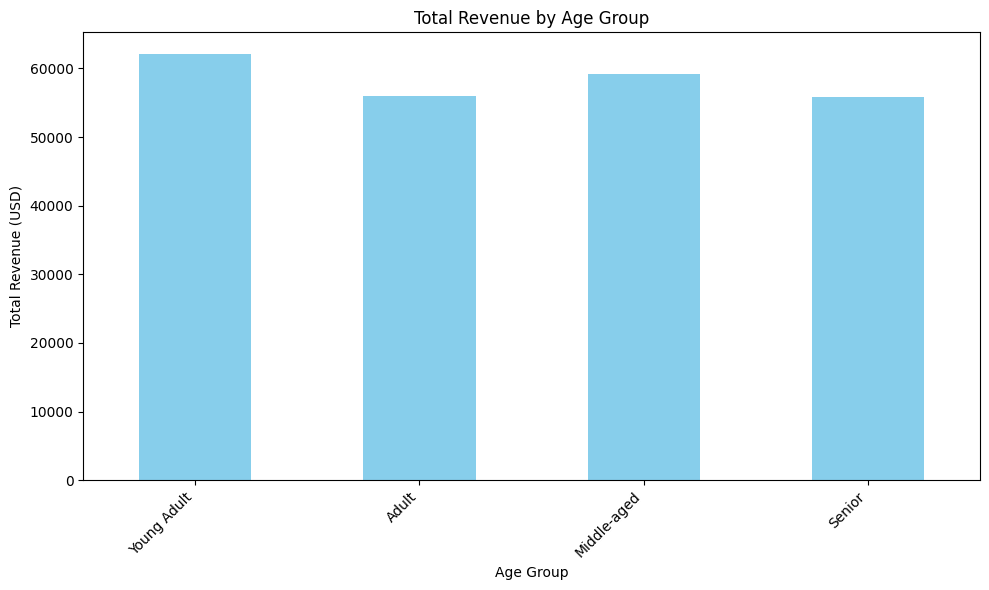

In [55]:
#Revenue Contribution by Age Group

revenue_by_age_group = df.groupby('age_group', observed=False)['purchase_amount'].sum()
print("Total Revenue by Age Group:\n", revenue_by_age_group)

plt.figure(figsize=(10, 6))
revenue_by_age_group.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()